### LIBRERIAS

In [52]:
# --- 1. Datos y Finanzas ---
import yfinance as yf          # Descarga de datos de mercado
import pandas as pd            # Manipulación de tablas (DataFrames)
import numpy as np             # Operaciones matemáticas y matrices
import pandas_ta as ta         # Indicadores técnicos (RSI, MACD, etc.)

# --- 2. Visualización y Geometría ---
import matplotlib.pyplot as plt    # Gráficos y diagramas
from scipy.spatial import ConvexHull # Cálculo de áreas de datos
from shapely.geometry import Polygon # Manejo de figuras geométricas

# --- 3. Machine Learning (Scikit-Learn) ---
from sklearn.ensemble import RandomForestClassifier # Algoritmo principal
from sklearn.model_selection import train_test_split # División de datos (Train/Test)
from sklearn.tree import export_graphviz             # Exportar estructura de árboles
from sklearn.preprocessing import LabelEncoder # Codificación de etiquetas




### CARGA DE DATOS

In [36]:
tickers = ["AAPL"]


data = yf.download(
    tickers,
    period="max",
    group_by="ticker",
    auto_adjust=False
)

rows = []

for ticker in tickers:
    if ticker not in data.columns.levels[0]:
        continue

    df_ticker = data[ticker].copy()
    df_ticker["date"] = df_ticker.index
    df_ticker["ticker"] = ticker

    rows.append(df_ticker.reset_index(drop=True))

df = pd.concat(rows, ignore_index=True)

df = df.dropna(
    subset=["Open", "High", "Low", "Close"]
)

df["asset_id"] = (
    df["ticker"] + "_" + df["date"].astype(str)
)

df = df[
    ["asset_id", "ticker", "date", "Open", "High", "Low", "Close", "Volume"]
].sort_values(["ticker", "date"])

df.columns = df.columns.str.lower()



[*********************100%***********************]  1 of 1 completed


### PREPROCESAMIENTO DE DATOS

In [37]:
# 1. Asegurar que la fecha sea tipo datetime (por si acaso)
df['date'] = pd.to_datetime(df['date'])

### CALCULA EL TARGET(ETIQUETA) PARA EL MODELO DE RANDOM FOREST

In [38]:
d = 14  # Por ejemplo, queremos predecir a 14 días vista

# 1. Calculamos la diferencia entre el precio futuro y el de hoy
# El shift(-d) mueve los precios de "dentro de 14 días" a la fila actual
diff = df['close'].shift(-d) - df['close']

# 2. Aplicamos la función Sign que pide el texto (+1 o -1)
df['target'] = np.where(diff > 0, 1, -1)

# 3. Aplicamos el dropna para que el target no quede incompleto
df.dropna()


Price,asset_id,ticker,date,open,high,low,close,volume,target
0,AAPL_1980-12-12,AAPL,1980-12-12,0.128348,0.128906,0.128348,0.128348,469033600,1
1,AAPL_1980-12-15,AAPL,1980-12-15,0.122210,0.122210,0.121652,0.121652,175884800,1
2,AAPL_1980-12-16,AAPL,1980-12-16,0.113281,0.113281,0.112723,0.112723,105728000,1
3,AAPL_1980-12-17,AAPL,1980-12-17,0.115513,0.116071,0.115513,0.115513,86441600,1
4,AAPL_1980-12-18,AAPL,1980-12-18,0.118862,0.119420,0.118862,0.118862,73449600,1
...,...,...,...,...,...,...,...,...,...
11411,AAPL_2026-03-25,AAPL,2026-03-25,254.100006,255.000000,251.600006,252.619995,28476700,-1
11412,AAPL_2026-03-26,AAPL,2026-03-26,252.119995,257.000000,250.770004,252.889999,41796700,-1
11413,AAPL_2026-03-27,AAPL,2026-03-27,253.899994,255.490005,248.070007,248.800003,47900000,-1
11414,AAPL_2026-03-30,AAPL,2026-03-30,250.070007,250.869995,245.509995,246.630005,39446200,-1


### SUAVIZADO COLUMNA CLOSE

In [39]:
# 1. Calculamos el suavizado exponencial (Exponential Weighted Moving Average)
# alpha=0.1 da mayor peso a los datos recientes pero mantiene una curva suave
df['close_smoothed'] = df['close'].ewm(alpha=0.1, adjust=False).mean()

# 2. Visualizamos el resultado
df["close_smoothed"]

0          0.128348
1          0.127678
2          0.126183
3          0.125116
4          0.124490
            ...    
11411    255.627231
11412    255.353507
11413    254.698157
11414    253.891342
11415    253.881207
Name: close_smoothed, Length: 11416, dtype: float64

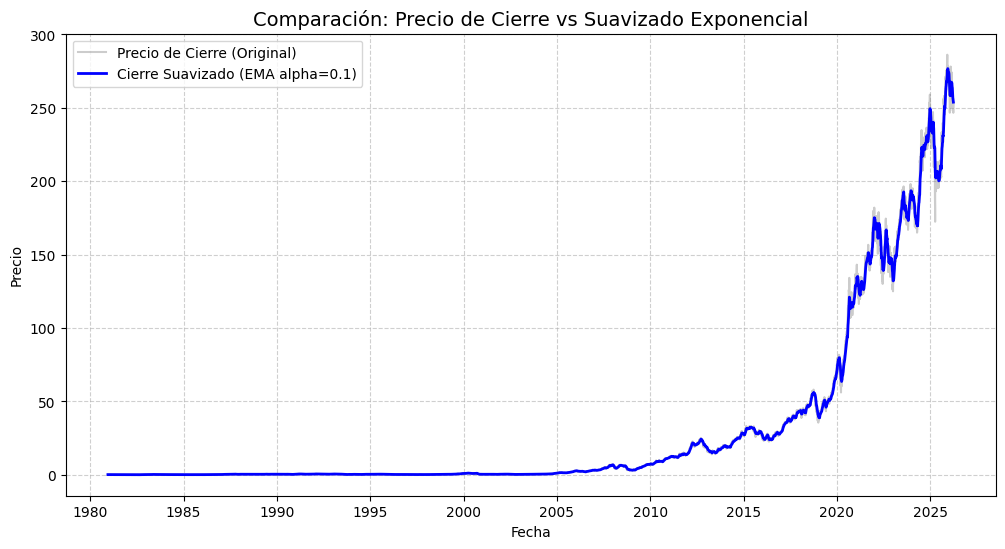

In [40]:
import matplotlib.pyplot as plt

# 1. Configurar el lienzo del gráfico
plt.figure(figsize=(12, 6))

# 2. Dibujar el precio real (con transparencia para destacar el suavizado)
plt.plot(df['date'], df['close'], label='Precio de Cierre (Original)', alpha=0.4, color='gray')

# 3. Dibujar la media exponencial (EMA) calculada previamente
plt.plot(df['date'], df['close_smoothed'], label='Cierre Suavizado (EMA alpha=0.1)', color='blue', linewidth=2)

# 4. Personalización y formato
plt.title('Comparación: Precio de Cierre vs Suavizado Exponencial', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Renderizar gráfico
plt.show()

## ¿Por qué usar `close_smoothed` en Random Forest?

En el análisis de series temporales financieras para clasificación (predecir si el precio sube o baja), la elección de las variables de entrada (*features*) es crítica. A continuación, se detalla por qué el **suavizado exponencial (EMA)** es superior al precio de **cierre (close) bruto** como predictor.

---

### 1. Filtrado de Ruido Blanco
El precio de cierre diario contiene "ruido": movimientos erráticos causados por micro-eventos o volatilidad intradía que no definen una tendencia.
* **El problema:** El Random Forest tiende a memorizar estos picos aleatorios (overfitting), creando reglas que no se repetirán.
* **La solución:** El `close_smoothed` elimina las fluctuaciones menores, permitiendo que el modelo identifique la **dirección subyacente**.

---

### 2. Estabilidad de las Fronteras de Decisión
Un Random Forest clasifica los datos mediante umbrales (ej. `if feature > 150.5`). 
* Si usamos el `close` bruto, el precio puede oscilar bruscamente alrededor del umbral por puro ruido, haciendo que las predicciones sean inestables.
* El `close_smoothed` cambia de forma progresiva, generando **nodos de decisión más robustos**.

---

### 3. Captura de la Inercia (Trend Following)
En finanzas, el "momento" es clave. Es más probable que el precio siga la tendencia actual a que la rompa de golpe.
* El suavizado actúa como una **memoria del precio**. Proporciona información sobre hacia dónde se ha movido el dinero recientemente, no solo dónde está "parado" hoy.

---

### 4. Evitar el "Overfitting" (Sobreajuste)
Si el modelo ve el precio real exacto, puede encontrar patrones falsos basados en valores específicos que no tienen validez estadística. 
Al usar una media, obligamos al modelo a generalizar basándose en **niveles de valor promedio**.

---


> **Conclusión:** Usamos el suavizado como predictor para que el Random Forest aprenda a leer la "corriente del río" y no solo el movimiento de cada "ola" individual.

# CALCULO INDICADORES TECNICOS PARA RANDOM FOREST

## RSI (Relative Strength Index)
El RSI mide la velocidad y el cambio de los movimientos de precios.

$$RS = \frac{\text{Media de cierres alcistas (Gains)}}{\text{Media de cierres bajistas (Losses)}}$$

$$RSI = 100 - \left( \frac{100}{1 + RS} \right)$$

In [41]:
# 1. Calculamos el RSI utilizando la librería pandas_ta
# 'length=d' asegura que el periodo sea dinámico según tu configuración
df['rsi'] = ta.rsi(df['close'], length=d)

# 2. Visualizamos el resultado
df['rsi']

0              NaN
1         0.000000
2         0.000000
3         3.035528
4         6.696765
           ...    
11411    42.573632
11412    43.046692
11413    37.947251
11414    35.541557
11415    47.392332
Name: rsi, Length: 11416, dtype: float64

### Funciones Principales del RSI (Relative Strength Index)

* **Identificación de niveles de "Sobrecompra" y "Sobreventa"** Ayuda a determinar cuándo un activo ha sido negociado en exceso.
    * **> 70 (Sobrecompra):** El precio ha subido mucho y podría estar cerca de una corrección o caída.
    * **< 30 (Sobreventa):** El precio ha bajado mucho y podría estar cerca de un rebote o subida.

* **Medición del "Momentum" (Velocidad del cambio)** Indica qué tan rápido se está moviendo el precio en una dirección.
    * **Cercano a 50:** El movimiento es lateral o lento.
    * **Cercano a 0 o 100:** El movimiento es extremadamente rápido y fuerte.

* **Detección de Divergencias** Sirve para alertar sobre un posible agotamiento de la tendencia actual.
    * **Ejemplo:** Si el precio sigue subiendo pero el **RSI baja**, significa que el activo está subiendo con menos intensidad y podría producirse un cambio de tendencia pronto.

## OSCILADOR ESTOCÁSTICO (STOCHASTIC OSCILLATOR)
El Oscilador Estocástico compara el precio de cierre de un activo con su rango de precios durante un período específico para identificar condiciones de sobrecompra o sobreventa.

$$\%K = \frac{\text{Cierre Actual} - \text{Mínimo Low}_n}{\text{Máximo High}_n - \text{Mínimo Low}_n} \times 100$$

In [42]:
# 1. Calculamos el Máximo y Mínimo de los últimos 'd' días
df['max'] = df['high'].rolling(window=d).max()
df['min'] = df['low'].rolling(window=d).min()

# 2. Aplicamos la fórmula: %K = 100 * (Cierre - Mínimo) / (Máximo - Mínimo)
df['stochastic_k'] = 100 * ((df['close'] - df['min']) / (df['max'] - df['min']))

# 3. Eliminamos los valores nulos (NaN) generados por la ventana móvil
df.dropna(inplace=True)

# Visualizamos el resultado
df['stochastic_k']

13       85.058387
14       78.162276
15       64.367938
16       48.781651
17       38.158461
           ...    
11411    40.169847
11412    41.808221
11413    16.990298
11414     6.738927
11415    61.607053
Name: stochastic_k, Length: 11403, dtype: float64

### El Oscilador Estocástico: Ubicación Relativa del Precio

El Oscilador Estocástico es un indicador de momentum que compara el precio de cierre de un activo con su rango de precios (máximo y mínimo) durante un periodo específico.

* **Cercanía al límite de 100 (Máximos del Periodo):** Indica que el precio actual está cerrando muy cerca del punto más alto de los últimos $n$ días. Técnicamente, esto sugiere que el activo tiene un fuerte impulso alcista, pero al acercarse al extremo superior, entra en zona de **sobrecompra**, alertando sobre una posible corrección o giro a la baja.

* **Cercanía al límite de 0 (Mínimos del Periodo):** Indica que el precio actual se encuentra cerca del punto más bajo del rango establecido. Esto refleja una fuerte presión vendedora que ha llevado al precio a sus niveles mínimos recientes, situándolo en zona de **sobreventa** y sugiriendo la posibilidad de un rebote o cambio de tendencia al alza.

* **Lógica de Reversión:** La premisa de este oscilador es que, en tendencias alcistas, los precios tienden a cerrar cerca de sus máximos, mientras que en tendencias bajistas, cierran cerca de sus mínimos. Cuando el precio no logra mantener esta relación (divergencia), el estocástico avisa de un cambio inminente.

---
**Configuración Estándar:**
Generalmente se utilizan los niveles **80** (sobrecompra) y **20** (sobreventa) como señales operativas más fiables que los extremos absolutos de 0 y 100.

## WILLIAMS %R

El Williams %R es un indicador de momentum que mide el nivel de sobrecompra o sobreventa de un activo financiero, similar al Oscilador Estocástico pero con una escala invertida.

$$\%R = \frac{\text{Máximo}_{\text{n}} - \text{Cierre}}{\text{Máximo}_{\text{n}} - \text{Mínimo}_{\text{n}}} \times -100$$

In [43]:
# 1. Determinamos el Máximo y Mínimo de los últimos 'd' días
highest_high = df['high'].rolling(window=d).max()
lowest_low   = df['low'].rolling(window=d).min()

# 2. Aplicamos la fórmula de Williams %R
# El resultado oscila entre 0 y -100
df['williams_r'] = ((highest_high - df['close']) / (highest_high - lowest_low)) * -100

# 3. Limpiamos los valores nulos iniciales producidos por la ventana móvil
df.dropna(inplace=True)


### Williams %R: El Espejo del Oscilador Estocástico

El **Williams %R** es un indicador de impulso que mide la relación entre el precio de cierre y el rango máximo-mínimo en un periodo determinado.

 Es considerado el inverso del Oscilador Estocástico rápido.

#### 1. Diferencia en la Escala
A diferencia de la mayoría de los osciladores, el Williams %R utiliza una escala negativa:
* **Rango:** Va de **0** (máximo) a **-100** (mínimo).
* **Interpretación:** Refleja qué tan cerca está el precio de "techo" de los últimos días.

#### 2. Niveles de Sobrecompra y Sobreventa
Debido a su escala invertida, los niveles se leen de la siguiente manera:
* **0 a -20 (Sobrecompra):** El precio está muy cerca de su máximo reciente. Indica una fuerza alcista extrema que podría estar agotándose.
* **-80 a -100 (Sobreventa):** El precio está cerca de su mínimo reciente. Indica que la presión vendedora ha sido muy fuerte y podría venir un rebote.

#### 3. Comparación con el Estocástico
* El **Estocástico** se fija en qué tan lejos está el precio del **mínimo** (por eso sube cuando el precio sube).
* El **Williams %R** se fija en qué tan lejos está el precio del **máximo** (por eso, si el valor es cercano a 0, significa que el precio está "tocando el techo").

> **Nota para el Modelo:** Al ser un indicador muy sensible al "ruido", el Williams %R es excelente para que el **Random Forest** detecte giros rápidos en el precio antes de que se confirmen en la tendencia suavizada.

## MACD (Moving Average Convergence Divergence)

El MACD es un indicador de tendencia y momentum que muestra la relación entre dos medias móviles exponenciales (EMA) de diferentes períodos. 

Se utiliza para identificar cambios en la fuerza, dirección, impulso y duración de una tendencia en el precio de un activo financiero.

$$MACD_{Line} = EMA_{12}(Close) - EMA_{26}(Close)$$

$$Signal_{Line} = EMA_{9}(MACD_{Line})$$

$$Histograma = MACD_{Line} - Signal_{Line}$$

In [44]:
# 1. Usamos el precio real (sin suavizar para evitar lag)
price = df['close'] 

# 2. Calculamos las dos EMAs rápidas y lentas
ema12 = price.ewm(span=12, adjust=False).mean()
ema26 = price.ewm(span=26, adjust=False).mean()

# 3. La línea MACD (Mide el impulso)
df['macd_line'] = ema12 - ema26

# 4. La Línea de Señal (Suavizado de la línea MACD)
df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()

# 5. Histograma (Diferencia entre impulso y señal)
df['macd_hist'] = df['macd_line'] - df['macd_signal']

df["macd_hist"]

26       0.000000
27       0.000107
28       0.000132
29      -0.000002
30      -0.000157
           ...   
11411   -0.402211
11412   -0.133398
11413   -0.187716
11414   -0.318761
11415    0.105117
Name: macd_hist, Length: 11390, dtype: float64

### MACD (Moving Average Convergence Divergence)

El MACD es un indicador de seguimiento de tendencia y momento. Para este modelo, se calcula sobre el **precio de cierre real** para mantener la sensibilidad ante los cambios del mercado.

#### Componentes:
* **MACD Line (12, 26):** Muestra la relación entre dos medias móviles exponenciales. Cuando es positiva, el impulso es alcista; cuando es negativa, es bajista.
* **Signal Line (9):** Una EMA de la propia línea MACD. Actúa como disparador de señales: los cruces entre la MACD Line y la Signal Line sugieren cambios de tendencia.
* **Histograma:** Representa la distancia entre la línea MACD y su señal. Si el histograma crece, la tendencia se está acelerando.


## PROC (Price Rate of Change)

El PROC es un indicador de momentum que mide el porcentaje de cambio en el precio de un activo financiero durante un período específico.

$$ROC = \left( \frac{\text{Cierre Actual} - \text{Cierre}_{n}}{\text{Cierre}_{n}} \right) \times 100$$

In [45]:
# 1. Calculamos la tasa de cambio del precio (Price Rate of Change)
# Compara el cierre actual con el de hace 'd' días
df["proc"] = (df["close"] - df["close"].shift(d)) / df["close"].shift(d)

# 2. Visualizamos el resultado
df["proc"]

26            NaN
27            NaN
28            NaN
29            NaN
30            NaN
           ...   
11411   -0.029467
11412   -0.017750
11413   -0.042635
11414   -0.054442
11415   -0.026916
Name: proc, Length: 11390, dtype: float64

### ROC (Rate of Change) - Tasa de Cambio

El ROC es un oscilador de momento que mide el cambio porcentual del precio actual respecto a un precio de hace **n** períodos. 

#### 1. Lógica del Indicador:
* **Valores Positivos (> 0):** El precio actual es mayor que el de hace $n$ días. Indica una tendencia alcista.
* **Valores Negativos (< 0):** El precio actual es menor que el de hace $n$ días. Indica una tendencia bajista.
* **Cruce de la línea cero:** Se considera una señal de cambio de tendencia o de aceleración del movimiento.

#### 2. Utilidad para el Random Forest:
Para una predicción con un horizonte de 14 días, el ROC de 14 periodos es una de las "features" más potentes. Le dice al modelo exactamente cuánto terreno ha ganado o perdido el activo en el mismo lapso de tiempo que intentamos predecir, ayudando a identificar si la inercia actual es sostenible.

#### 3. Diferencia con el Momentum:
Mientras que el indicador de "Momentum" simple da la diferencia en puntos (Precio - Precio$_n$), el **ROC** la da en **porcentaje**, lo que permite comparar la volatilidad de forma normalizada independientemente del valor nominal del activo.

## OBV (On-Balance Volume)

El OBV es un indicador técnico que relaciona el volumen de negociación con los movimientos de precios para medir la presión de compra y venta.

Si $Cierre_{hoy} > Cierre_{ayer}$:$$OBV_{actual} = OBV_{anterior} + Volumen_{hoy}$$Si $Cierre_{hoy} < Cierre_{ayer}$:$$OBV_{actual} = OBV_{anterior} - Volumen_{hoy}$$Si $Cierre_{hoy} = Cierre_{ayer}$:$$OBV_{actual} = OBV_{anterior}$$

In [46]:
# Inicializar OBV
df["obv"] = 0.0  

# 2. Calcular OBV
for i in range(1, len(df)):
    
    if df["close"].iloc[i] > df["close"].iloc[i-1]:
        
        df.iloc[i, df.columns.get_loc("obv")] = df["obv"].iloc[i-1] + df["volume"].iloc[i]
        
    elif df["close"].iloc[i] < df["close"].iloc[i-1]:
        
        df.iloc[i, df.columns.get_loc("obv")] = df["obv"].iloc[i-1] - df["volume"].iloc[i]
        
    else:
        
        df.iloc[i, df.columns.get_loc("obv")] = df["obv"].iloc[i-1]

### OBV (On-Balance Volume)

El OBV es un indicador de momento que relaciona el volumen con los cambios en el precio. Se utiliza principalmente para confirmar tendencias y detectar divergencias.

#### 1. Funcionamiento:
* **Flujo Positivo:** Cuando el precio de cierre actual es superior al anterior, el volumen del periodo se suma al total acumulado del OBV.
* **Flujo Negativo:** Cuando el cierre es inferior, el volumen se resta del total acumulado.

#### 2. Utilidad para el Random Forest:
El OBV es fundamental para el modelo porque introduce la variable del **Volumen**, que los osciladores como el RSI o el MACD no suelen tener en cuenta. 
* Ayuda al modelo a distinguir entre un movimiento de precio con "fuerza real" (alto volumen) y un movimiento engañoso o "ruido" (bajo volumen).
* Es especialmente útil para predicciones a **14 días**, ya que las tendencias de volumen suelen ser más estables que las fluctuaciones de precio a corto plazo.

# ELECCIÓN DE FEATURES PARA RANDOM FOREST

In [47]:
df.columns

Index(['asset_id', 'ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'target', 'close_smoothed', 'rsi', 'max', 'min', 'stochastic_k',
       'williams_r', 'macd_line', 'macd_signal', 'macd_hist', 'proc', 'obv'],
      dtype='str', name='Price')

COLUMNAS A NO UTILIZAR PARA RANDOM FOREST:

- `asset_id` (Identificador único del activo, no aporta información predictiva)
- `date` (Fecha y hora, no es útil para el modelo sin un procesamiento adicional
- `target` (Es la variable que queremos predecir, no debe ser una feature de entrada)
- `max` (Máximo desde hace 14 días)
- `min` (Mínimo desde hace 14 días)


### Justificación del uso de Precios Crudos vs. Suavizados

En el entrenamiento del Random Forest, se ha optado por mantener los valores de `open`, `high`, `low` y `close` sin suavizar por los siguientes motivos técnicos:

* **Preservación de Volatilidad:** Los valores máximos (`high`) y mínimos (`low`) contienen información crítica sobre el rechazo del precio y niveles de soporte/resistencia que se pierden al aplicar filtros de suavizado.
* **Reducción del Lag Temporal:** El suavizado introduce un retraso artificial en los datos de entrada, lo que restaría precisión a la ventana de predicción de 14 días.
* **Capacidad de Filtrado del Modelo:** Al ser un conjunto de árboles de decisión, el Random Forest es robusto ante el ruido estocástico y es capaz de jerarquizar la importancia de las variaciones bruscas frente a la tendencia principal.
* **Dualidad de Información:** Se incluye la columna `close_smoothed` como una característica adicional, permitiendo que el modelo compare el precio actual (volatilidad) con su media tendencial (dirección).

# EXPLICACIÓN PORQUE RANDOM FOREST

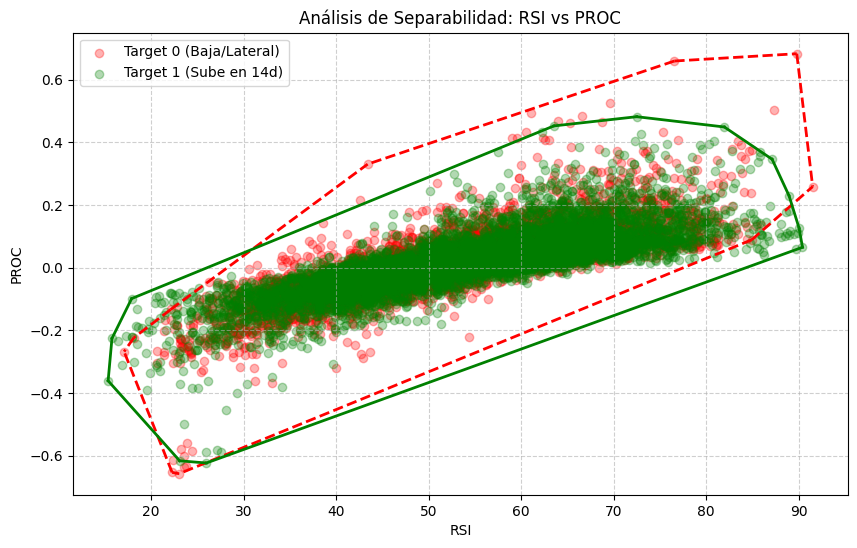

Área de solapamiento entre clases: 37.9923
Aviso: Hay solapamiento. El Random Forest necesitará más variables para distinguir las clases.


In [48]:
# 1. Preparación de los datos (Usamos dos indicadores como ejemplo de ejes X e Y)
# El Random Forest usa muchas dimensiones, pero para el Hull necesitamos 2D para visualizar
features_visual = ['rsi', 'proc']  # Puedes cambiar estos por los que quieras comparar
data_plot = df.dropna(subset=features_visual + ['target'])

# Separamos las dos clases según tu Target (0: Baja/Lateral, 1: Sube en 14 días)
class0 = data_plot[data_plot['target'] == -1][features_visual].values
class1 = data_plot[data_plot['target'] == 1][features_visual].values

# 2. Cálculo de los Convex Hulls
hull0 = ConvexHull(class0)
hull1 = ConvexHull(class1)

# 3. Dibujar el gráfico profesional
plt.figure(figsize=(10, 6))

# Puntos de las clases
plt.scatter(class0[:,0], class0[:,1], color='red', alpha=0.3, label='Target 0 (Baja/Lateral)')
plt.scatter(class1[:,0], class1[:,1], color='green', alpha=0.3, label='Target 1 (Sube en 14d)')

# Dibujar la envolvente (Hull) de la Clase 0
for simplex in hull0.simplices:
    plt.plot(class0[simplex, 0], class0[simplex, 1], 'r--', lw=2)

# Dibujar la envolvente (Hull) de la Clase 1
for simplex in hull1.simplices:
    plt.plot(class1[simplex, 0], class1[simplex, 1], 'g-', lw=2)

plt.title(f'Análisis de Separabilidad: {features_visual[0].upper()} vs {features_visual[1].upper()}')
plt.xlabel(features_visual[0].upper())
plt.ylabel(features_visual[1].upper())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Cálculo de Intersección (¿Qué tanto se solapan?)
poly0 = Polygon(class0[hull0.vertices])
poly1 = Polygon(class1[hull1.vertices])

intersection_area = poly0.intersection(poly1).area
print(f"Área de solapamiento entre clases: {intersection_area:.4f}")

if intersection_area > 0:
    print("Aviso: Hay solapamiento. El Random Forest necesitará más variables para distinguir las clases.")
else:
    print("Las clases son linealmente separables en este plano.")

### Estrategia de Clasificación: ¿Por qué Random Forest?

En el análisis de datos financieros, la separación entre las señales de "Compra" (Subida) y "Venta" (Bajada) rara vez es sencilla. A continuación, se justifica la elección del modelo actual frente a métodos tradicionales.

#### 1. Limitaciones de los Modelos Lineales (LDA)

El **Análisis Discriminante Lineal (LDA)** busca encontrar una combinación de características que separen las clases mediante una **línea recta** (o un hiperplano en varias dimensiones). 

* **El Problema:** En el trading, los indicadores como el RSI, MACD o el volumen se mezclan de forma no lineal. 
* **Resultado:** Como las clases no pueden separarse con una simple trayectoria recta, el LDA falla al intentar distinguir los patrones complejos del mercado.

#### 2. La Solución: Random Forest Classifier

Para superar estas limitaciones, hemos implementado un **Random Forest Classifier**. A diferencia de los modelos lineales, este algoritmo de ensamble basado en árboles de decisión es ideal para datos "mezclados".



##### ¿Por qué Random Forest es superior en este contexto?

* **Flexibilidad No Lineal:** No está restringido a usar líneas rectas para dividir los datos.
* **Segmentación del Espacio:** En lugar de una frontera única, el modelo divide el espacio de características en múltiples "cajas" o regiones pequeñas.
* **Modelado de Formas Complejas:** Al combinar cientos de árboles de decisión, el algoritmo puede crear fronteras de decisión con **formas complejas y adaptativas**.
* **Robustez ante el Ruido:** Es capaz de separar datos que parecen mezclados visualmente, identificando patrones ocultos en dimensiones superiores.

> **Conclusión:** Mientras que un modelo lineal intenta forzar una frontera simple, **Random Forest** se adapta a la "geometría" real de los datos financieros, permitiendo una clasificación mucho más precisa para nuestra predicción.

# EXPLICACIÓN RANDOM FOREST

### **Random Forest: El Poder de la Decisión Colectiva**

* **Fundamento:** Combina múltiples **árboles de clasificación** que segmentan los datos mediante preguntas binarias sobre sus características ($X_d$).
* **Métricas de Corte:** Utiliza la **Impureza de Gini** ($G = 1 - \sum p_i^2$) o la **Entropía** para maximizar la "pureza" de los grupos resultantes.
* **El Problema:** Un solo árbol suele caer en **overfitting** (bajo sesgo, pero alta varianza), memorizando el ruido del pasado en lugar de patrones reales.

* **La Solución (Bagging):** Mediante *Bootstrap Aggregating*, cada árbol se entrena con subconjuntos aleatorios de datos y variables, aportando una perspectiva única.
* **Resultado:** Se reduce la varianza global al promediar los "votos" de todo el bosque, logrando un modelo robusto que **generaliza** con precisión ante datos nuevos.


---

**Aviso de Riesgo:** El uso de algoritmos de Machine Learning como Random Forest en mercados financieros no garantiza resultados positivos. La naturaleza volátil de los activos puede invalidar los patrones históricos detectados, lo que conlleva un **alto riesgo de pérdida de capital**. Esta información es exclusivamente educativa y no constituye asesoramiento financiero.

In [49]:
# 1️⃣ Preparación de datos
features = [
    'open', 'high', 'low', 'close', 'volume', 
    'close_smoothed', 'rsi', 'stochastic_k', 
    'williams_r', 'macd_line', 'macd_signal', 
    'macd_hist', 'proc', 'obv'
]

# Limpieza de NaNs para evitar errores en el modelo
X = df[features].dropna()
y = df.loc[X.index, 'target'] 

# 2️⃣ Separar en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Configurar Random Forest
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42
)

# 4️⃣ Entrenar el modelo
rf.fit(X_train, y_train)

# 5️⃣ Ejecutar predicciones
y_pred = rf.predict(X_test)


### **Configuración de Hiperparámetros: Random Forest**

La siguiente tabla resume los parámetros principales del modelo que se pueden ajustar para optimizar el rendimiento y controlar el sobreajuste (*overfitting*):

| Parámetro | Qué hace / Modificación | Para qué sirve |
| :--- | :--- | :--- |
| **`n_estimators`** | Número de árboles en el bosque. | **Más árboles** → Mayor estabilidad y menor varianza, pero aumenta el tiempo de cálculo. |
| **`max_depth`** | Profundidad máxima de cada árbol. | **Limitar profundidad** → Ayuda a reducir el *overfitting*. Si es muy profundo, el modelo memoriza el ruido. |
| **`min_samples_split`**| Mínimo de datos requeridos para dividir un nodo. | **Aumentarlo** → Crea árboles menos complejos y fomenta la generalización. |
| **`min_samples_leaf`** | Mínimo de datos que debe tener una hoja final. | **Aumentarlo** → Evita hojas con muy pocos datos, reduciendo el impacto del ruido. |
| **`max_features`** | Características consideradas en cada división. | **Menos features** → Aumenta la diversidad entre árboles. **Más features** → Árboles individuales más fuertes. |
| **`bootstrap`** | Uso de muestras con reemplazo (True/False). | **True** → Habilita el *bagging*, mejorando la estabilidad del modelo frente a cambios en los datos. |

## EXPORTAR ARBOLES

In [50]:
# Exportar solo 5 árboles a .dot
for i, tree in enumerate(rf.estimators_[:5]):
    # El contenido del bucle DEBE tener sangría (indentación)
    filename = f"arboles/tree_{i}.dot"
    
    export_graphviz(
        tree, 
        out_file=filename, 
        feature_names=features,  # Usamos tu lista de columnas real
        class_names=["Baja/Lat", "Sube"], # Nombres de tus clases
        rounded=True,
        filled=True,
        max_depth=3 # Limitamos profundidad para que el gráfico no sea gigante
    )


### **Visualización de Árboles en VS Code**

Para visualizar los archivos `.dot` generados por el modelo directamente en tu editor, sigue estos pasos:

1. Ve a la pestaña de **Extensiones** en VS Code (`Ctrl+Shift+X`).
2. Busca e instala la extensión: **"Graphviz Interactive Preview"**.
3. Abre cualquier archivo `tree_x.dot` que hayas generado.
4. Presiona el botón de **Preview** (icono de ojo o `Ctrl+Shift+V`) para ver el diagrama del árbol de decisión en tiempo real.

# ENTENDER Y MEJORAR EL MODELO DE RANDOM FOREST

In [53]:

# ----------------------------
# 2. Convertir clases a enteros
# ----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# ----------------------------
# 3. Entrenar Random Forest
# ----------------------------
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train_enc)

# ----------------------------
# 4. Probabilidades de cada clase
# ----------------------------
probs = rf.predict_proba(X_test)

# ----------------------------
# 5. Calcular margin
# ----------------------------
margins = []

for i in range(len(y_test_enc)):
    true_class_index = y_test_enc[i]  # ahora es un entero
    p_correct = probs[i][true_class_index]
    
    # Mejor clase incorrecta
    p_others = np.delete(probs[i], true_class_index)
    p_max_other = np.max(p_others)
    
    # Margin
    margin = p_correct - p_max_other
    margins.append(margin)

margins = np.array(margins)

# ----------------------------
# 6. Calcular métricas
# ----------------------------
margin_mean = margins.mean()           # Strength
pe_star = np.mean(margins < 0)        # Error de generalización
margin_var = margins.var()             # Varianza
error_bound = margin_var / (margin_mean ** 2)  # Cota del error

# ----------------------------
# 7. Mostrar resultados
# ----------------------------
print("Margin medio (strength):", margin_mean)
print("Error de generalización (PE*):", pe_star)
print("Varianza del margin:", margin_var)
print("Cota del error:", error_bound)

Margin medio (strength): 0.3897363796133568
Error de generalización (PE*): 0.15685413005272408
Varianza del margin: 0.1419459761984921
Cota del error: 0.9345040606539524


c:\Users\jorge\miniconda3\envs\proyecto_finanzas\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jorge\miniconda3\envs\proyecto_finanzas\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jorge\miniconda3\envs\proyecto_finanzas\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jorge\miniconda3\envs\proyecto_finanzas\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


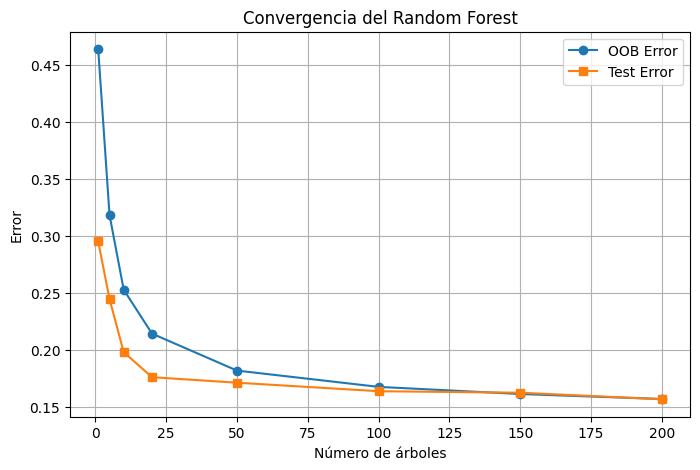

In [ ]:
# Lista de números de árboles
n_estimators_list = [1, 5, 10, 20, 50, 100, 150, 200]

# Almacenar errores
oob_errors = []
test_errors = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X_train, y_train)
    
    # Error OOB
    oob_error = 1 - rf.oob_score_
    oob_errors.append(oob_error)
    
    # Error en test set
    test_error = 1 - rf.score(X_test, y_test)
    test_errors.append(test_error)

# Graficar convergencia
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, oob_errors, marker='o', label='OOB Error')
plt.plot(n_estimators_list, test_errors, marker='s', label='Test Error')
plt.xlabel('Número de árboles')
plt.ylabel('Error')
plt.title('Convergencia del Random Forest')
plt.legend()
plt.grid(True)
plt.show()

## 🌲 Random Forest — Resumen clave

---

### 🔹 1. Margin (margen)

**Fórmula:**

$$
mg(X,Y) = \text{promedio votos correctos} - \max(\text{votos incorrectos})
$$

👉 Mide cuánto gana la clase correcta frente a la mejor alternativa  

- ✅ Margin > 0 → predicción correcta  
- ❌ Margin < 0 → error  

---

### 🔹 2. Error de generalización

$$
PE^* = P(mg(X,Y) < 0)
$$

👉 Probabilidad de equivocarse  

- Es el % de márgenes negativos  
- ≈ error en datos nuevos (test / OOB)

---

### 🔹 3. Random Forest como conjunto

$$
h(x, \theta_k)
$$

- \(x\): datos de entrada  
- \(\theta_k\): muestra bootstrap  

👉 Cada árbol es distinto → **diversidad**

---

### 🔹 4. Convergencia

👉 Más árboles → el error:

- Baja mucho al principio  
- Luego baja poco  
- Finalmente se estabiliza  

✔ No sobreajusta al añadir más árboles  

---

### 🔹 5. Margin del RF

$$
margin_{RF}(x,y) = P(\text{correcto}) - P(\text{mejor incorrecto})
$$

👉 Igual que el margin, pero en probabilidades  

---

### 🔹 6. Strength (fuerza)

$$
s = E(margin)
$$

👉 Margin medio  

- Alto → modelo fuerte  
- Bajo → modelo débil  

---

### 🔹 7. Cota del error

$$
Error \le \frac{Var(margin)}{s^2}
$$

👉 El error depende de:

- Varianza ↑ → peor  
- Strength ↑ → mejor  

---

### 🔥 Conclusión

Para un buen Random Forest:

- ✔ Árboles fuertes  
- ✔ Árboles diversos (baja correlación)  